# Hierarchical Clustering

In [1]:
# Import libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Check current working directory

print(os.getcwd())

c:\Users\Greesha Vaishnavi\Desktop\dsprojects\E_Commerce_Customer_Segmentation\research


In [3]:
# Load transformed data

rfm = pd.read_csv("../artifacts/data_transformation/customer_rfm.csv")

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [4]:
# Check data shape

print("Shape:", rfm.shape)

Shape: (4338, 4)


In [5]:
# Check columns

print("Columns:", rfm.columns.tolist())

Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary']


In [6]:
# Check missing values

print(rfm.isnull().sum())

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64


In [7]:
# Separate customer ID and features

customer_ids = rfm["CustomerID"]

X = rfm[["Recency", "Frequency", "Monetary"]]

print("Customer IDs shape:", customer_ids.shape)
print("Features shape:", X.shape)

Customer IDs shape: (4338,)
Features shape: (4338, 3)


# Data Preprocessing

In [8]:
# Check skewness

print(X.skew())

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64


In [9]:
# Apply log transformation

X_log = np.log1p(X)

X_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


In [10]:
# Check skewness after log transformation

print(X_log.skew())

Recency     -0.379169
Frequency    1.208652
Monetary     0.396599
dtype: float64


In [11]:
# Import StandardScaler

from sklearn.preprocessing import StandardScaler

In [12]:
# Scale features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_log.columns,
    index=X_log.index
)

X_scaled.head()

,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


In [13]:
# Check scaled features

print("Mean:")
print(X_scaled.mean())

print("\nStandard Deviation:")
print(X_scaled.std())

Mean:
Recency     -8.025955e-17
Frequency   -8.189750e-18
Monetary    -3.734526e-16
dtype: float64

Standard Deviation:
Recency      1.000115
Frequency    1.000115
Monetary     1.000115
dtype: float64


# Baseline Hierarchical Clustering

In [14]:
# Import AgglomerativeClustering

from sklearn.cluster import AgglomerativeClustering

In [15]:
# Create baseline Hierarchical model

baseline_hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

In [16]:
# Train baseline Hierarchical model

baseline_labels = baseline_hierarchical.fit_predict(X_scaled)

In [17]:
# Add baseline cluster labels

rfm["Baseline_Cluster"] = baseline_labels

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Baseline_Cluster
0,12346.0,326,1,77183.60,2
1,12347.0,2,7,4310.00,1
2,12348.0,75,4,1797.24,2
3,12349.0,19,1,1757.55,2
4,12350.0,310,1,334.40,0


In [18]:
# Import clustering evaluation metrics

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [19]:
# Calculate baseline evaluation metrics

baseline_silhouette = silhouette_score(
    X_scaled,
    baseline_labels
)

baseline_davies_bouldin = davies_bouldin_score(
    X_scaled,
    baseline_labels
)

baseline_calinski = calinski_harabasz_score(
    X_scaled,
    baseline_labels
)

In [20]:
# Print baseline evaluation results

print("Baseline Hierarchical Clustering Evaluation")
print(f"Silhouette Score: {baseline_silhouette:.4f}")
print(f"Davies-Bouldin Index: {baseline_davies_bouldin:.4f}")
print(f"Calinski-Harabasz Score: {baseline_calinski:.4f}")

Baseline Hierarchical Clustering Evaluation
Silhouette Score: 0.2800
Davies-Bouldin Index: 1.0992
Calinski-Harabasz Score: 2739.5701


In [21]:
# Check baseline cluster distribution

print(
    rfm["Baseline_Cluster"]
    .value_counts()
    .sort_index()
)

Baseline_Cluster
0    1716
1     762
2    1517
3     343
Name: count, dtype: int64


# Hyperparameter Experiment

In [22]:
# Test different numbers of clusters

silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for k in range(2, 11):
    
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    labels = model.fit_predict(X_scaled)
    
    silhouette = silhouette_score(
        X_scaled,
        labels
    )
    
    davies_bouldin = davies_bouldin_score(
        X_scaled,
        labels
    )
    
    calinski_harabasz = calinski_harabasz_score(
        X_scaled,
        labels
    )
    
    silhouette_scores.append(silhouette)
    davies_bouldin_scores.append(davies_bouldin)
    calinski_harabasz_scores.append(calinski_harabasz)

In [23]:
# Print experiment results

for k, silhouette, davies_bouldin, calinski_harabasz in zip(range(2, 11),
    silhouette_scores,
    davies_bouldin_scores,
    calinski_harabasz_scores
):
    
    print(
        f"K = {k}, "
        f"Silhouette = {silhouette:.4f}, "
        f"Davies-Bouldin = {davies_bouldin:.4f}, "
        f"Calinski-Harabasz = {calinski_harabasz:.2f}"
    )

K = 2, Silhouette = 0.4040, Davies-Bouldin = 0.9405, Calinski-Harabasz = 3168.23
K = 3, Silhouette = 0.2843, Davies-Bouldin = 1.1327, Calinski-Harabasz = 2960.25
K = 4, Silhouette = 0.2800, Davies-Bouldin = 1.0992, Calinski-Harabasz = 2739.57
K = 5, Silhouette = 0.2805, Davies-Bouldin = 1.0308, Calinski-Harabasz = 2754.95
K = 6, Silhouette = 0.2660, Davies-Bouldin = 1.1079, Calinski-Harabasz = 2606.21
K = 7, Silhouette = 0.2582, Davies-Bouldin = 1.1081, Calinski-Harabasz = 2484.47
K = 8, Silhouette = 0.2515, Davies-Bouldin = 1.1294, Calinski-Harabasz = 2386.93
K = 9, Silhouette = 0.2500, Davies-Bouldin = 1.1571, Calinski-Harabasz = 2325.11
K = 10, Silhouette = 0.2167, Davies-Bouldin = 1.1573, Calinski-Harabasz = 2230.00


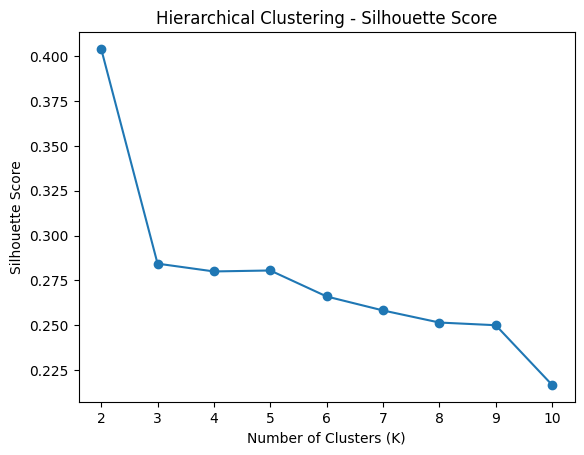

In [24]:
# Plot silhouette scores

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Hierarchical Clustering - Silhouette Score")

plt.show()

In [25]:
# Find best K based on silhouette score

best_k = range(2, 11)[
    np.argmax(silhouette_scores)
]

best_silhouette = max(silhouette_scores)

print("Best K:", best_k)
print("Best Silhouette Score:", round(best_silhouette, 4))

Best K: 2
Best Silhouette Score: 0.404


In [26]:
# Import dendrogram functions

from scipy.cluster.hierarchy import dendrogram, linkage

In [27]:
# Create hierarchical linkage matrix

linkage_matrix = linkage(
    X_scaled,
    method="ward"
)

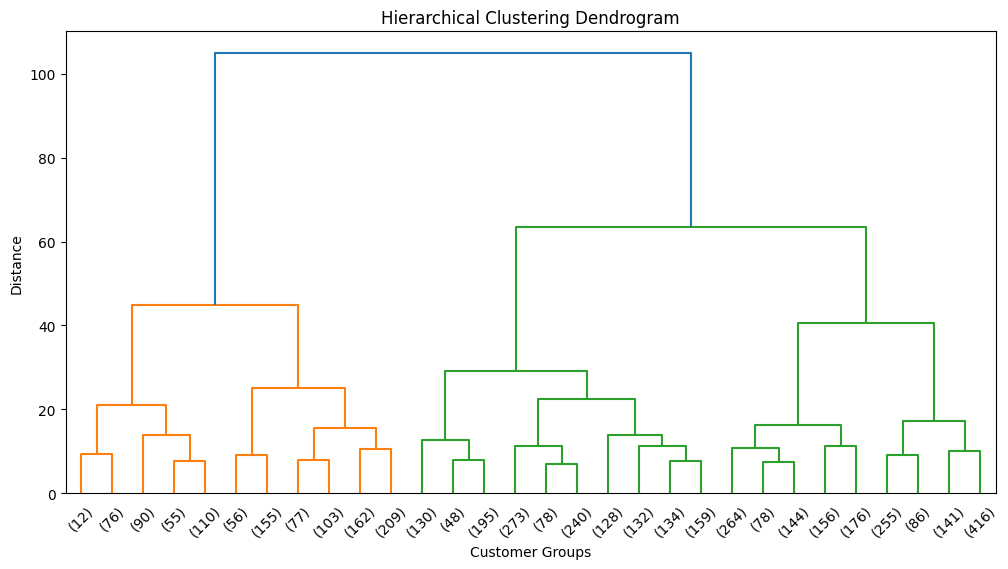

In [28]:
# Plot dendrogram

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30
)

plt.xlabel("Customer Groups")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()

# Hyperparameter Tuning

In [29]:
# Test different Hierarchical Clustering configurations

tuning_results = []

for k in range(2, 11):
    
    for linkage_method in ["ward", "complete", "average", "single"]:
        
        if linkage_method == "ward":
            
            model = AgglomerativeClustering(
                n_clusters=k,
                linkage=linkage_method,
                metric="euclidean"
            )
            
            labels = model.fit_predict(X_scaled)
            
            silhouette = silhouette_score(
                X_scaled,
                labels
            )
            
            davies_bouldin = davies_bouldin_score(
                X_scaled,
                labels
            )
            
            calinski_harabasz = calinski_harabasz_score(
                X_scaled,
                labels
            )
            
            tuning_results.append({
                "n_clusters": k,
                "linkage": linkage_method,
                "metric": "euclidean",
                "silhouette_score": silhouette,
                "davies_bouldin_score": davies_bouldin,
                "calinski_harabasz_score": calinski_harabasz
            })
        
        else:
            
            for metric in ["euclidean", "manhattan", "cosine"]:
                
                model = AgglomerativeClustering(
                    n_clusters=k,
                    linkage=linkage_method,
                    metric=metric
                )
                
                labels = model.fit_predict(X_scaled)
                
                silhouette = silhouette_score(
                    X_scaled,
                    labels
                )
                
                davies_bouldin = davies_bouldin_score(
                    X_scaled,
                    labels
                )
                
                calinski_harabasz = calinski_harabasz_score(
                    X_scaled,
                    labels
                )
                
                tuning_results.append({
                    "n_clusters": k,
                    "linkage": linkage_method,
                    "metric": metric,
                    "silhouette_score": silhouette,
                    "davies_bouldin_score": davies_bouldin,
                    "calinski_harabasz_score": calinski_harabasz
                })

In [30]:
# Create tuning results DataFrame

tuning_results_df = pd.DataFrame(
    tuning_results
)

tuning_results_df.head()

,n_clusters,linkage,metric,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,ward,euclidean,0.404010,0.940467,3168.225114
1,2,complete,euclidean,0.401205,0.941239,3929.776644
2,2,complete,manhattan,0.384606,1.011673,1786.263481
3,2,complete,cosine,0.377526,0.993440,3376.741497
4,2,average,euclidean,0.549501,0.573519,378.220724


In [31]:
# Sort tuning results by silhouette score

tuning_results_df.sort_values(
    "silhouette_score",
    ascending=False
).head(10)

,n_clusters,linkage,metric,silhouette_score,davies_bouldin_score,calinski_harabasz_score
7,2,single,euclidean,0.562794,0.310689,8.128185
8,2,single,manhattan,0.562794,0.310689,8.128185
4,2,average,euclidean,0.549501,0.573519,378.220724
5,2,average,manhattan,0.479653,0.641376,1035.264664
14,3,average,euclidean,0.469754,0.765722,199.781417
17,3,single,euclidean,0.458959,0.363510,6.647859
18,3,single,manhattan,0.458959,0.363510,6.647859
24,4,average,euclidean,0.431648,0.505259,134.517868
15,3,average,manhattan,0.424608,0.604191,527.923735
27,4,single,euclidean,0.419190,0.459406,8.833080


In [32]:
# Get best Hierarchical configuration

best_result = tuning_results_df.sort_values(
    "silhouette_score",
    ascending=False
).iloc[0]

best_result

n_clusters                         2
linkage                       single
metric                     euclidean
silhouette_score            0.562794
davies_bouldin_score        0.310689
calinski_harabasz_score     8.128185
Name: 7, dtype: object

In [33]:
# Display best parameters

print("Best Parameters")
print("n_clusters:", int(best_result["n_clusters"]))
print("linkage:", best_result["linkage"])
print("metric:", best_result["metric"])

Best Parameters
n_clusters: 2
linkage: single
metric: euclidean


In [34]:
# Create tuned Hierarchical model

tuned_hierarchical = AgglomerativeClustering(
    n_clusters=int(best_result["n_clusters"]),
    linkage=best_result["linkage"],
    metric=best_result["metric"]
)

In [35]:
# Train tuned Hierarchical model

tuned_labels = tuned_hierarchical.fit_predict(
    X_scaled
)

In [36]:
# Add tuned cluster labels

rfm["Tuned_Cluster"] = tuned_labels

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Baseline_Cluster,Tuned_Cluster
0,12346.0,326,1,77183.60,2,0
1,12347.0,2,7,4310.00,1,0
2,12348.0,75,4,1797.24,2,0
3,12349.0,19,1,1757.55,2,0
4,12350.0,310,1,334.40,0,0


In [37]:
# Calculate tuned evaluation metrics

tuned_silhouette = silhouette_score(
    X_scaled,
    tuned_labels
)

tuned_davies_bouldin = davies_bouldin_score(
    X_scaled,
    tuned_labels
)

tuned_calinski = calinski_harabasz_score(
    X_scaled,
    tuned_labels
)

In [38]:
# Print tuned evaluation results

print("Tuned Hierarchical Clustering Evaluation")
print(f"Silhouette Score: {tuned_silhouette:.4f}")
print(f"Davies-Bouldin Index: {tuned_davies_bouldin:.4f}")
print(f"Calinski-Harabasz Score: {tuned_calinski:.2f}")

Tuned Hierarchical Clustering Evaluation
Silhouette Score: 0.5628
Davies-Bouldin Index: 0.3107
Calinski-Harabasz Score: 8.13


# Baseline vs Tuned

In [40]:
# Compare baseline and tuned models

comparison = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Score"
    ],
    "Baseline": [
        baseline_silhouette,
        baseline_davies_bouldin,
        baseline_calinski
    ],
    "Tuned": [
        tuned_silhouette,
        tuned_davies_bouldin,
        tuned_calinski
    ]
})

comparison

,Metric,Baseline,Tuned
0,Silhouette Score,0.279991,0.562794
1,Davies-Bouldin Index,1.099234,0.310689
2,Calinski-Harabasz Score,2739.570129,8.128185


In [41]:
# Use tuned clusters for final profiling

rfm["Cluster"] = tuned_labels

In [42]:
# Create customer segment profile

cluster_profile = (
    rfm.groupby("Cluster")[
        ["Recency", "Frequency", "Monetary"]
    ]
    .mean()
    .round(2)
)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,92.56,4.27,2010.32
1,1.00,2.00,168472.50


In [43]:
# Add customer count

cluster_profile["CustomerCount"] = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_profile

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,92.56,4.27,2010.32,4337
1,1.00,2.00,168472.50,1


In [44]:
# Add cluster percentage

cluster_profile["Percentage"] = (
    cluster_profile["CustomerCount"]
    / len(rfm)
    * 100
).round(2)

cluster_profile

,Recency,Frequency,Monetary,CustomerCount,Percentage
Cluster,,,,,
0,92.56,4.27,2010.32,4337,99.98
1,1.00,2.00,168472.50,1,0.02


In [45]:
# Sort clusters by monetary value

cluster_profile.sort_values(
    "Monetary",
    ascending=False
)

,Recency,Frequency,Monetary,CustomerCount,Percentage
Cluster,,,,,
1,1.00,2.00,168472.50,1,0.02
0,92.56,4.27,2010.32,4337,99.98


In [46]:
# Save Hierarchical tuning results

tuning_results_df.to_csv(
    "../artifacts/data_transformation/hierarchical_tuning_results.csv",
    index=False
)

In [47]:
# Save customer clusters

rfm.to_csv(
    "../artifacts/data_transformation/customer_clusters_hierarchical.csv",
    index=False
)

In [48]:
# Save cluster profile

cluster_profile.to_csv(
    "../artifacts/data_transformation/hierarchical_cluster_profile.csv"
)

In [49]:
# Confirm saved results

print("Hierarchical Clustering experiment completed successfully.")

Hierarchical Clustering experiment completed successfully.


# Hierarchical Clustering Key Insights

- Hierarchical Agglomerative Clustering was applied to the customer-level RFM data after log transformation and standardization.
- A baseline model was created using an initial K value of 4 and Ward linkage.
- The baseline model was evaluated using Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Score.
- Different numbers of clusters were evaluated to understand the effect of K on clustering quality.
- A dendrogram was used to visualize the hierarchical structure of the customer groups.
- Different linkage methods and distance metrics were tested during hyperparameter tuning.
- The best configuration was selected based on the clustering evaluation results.
- The tuned model was evaluated and compared with the baseline model.
- Customer clusters were profiled using Recency, Frequency, and Monetary values.
- The Hierarchical Clustering results will be compared with K-Means, DBSCAN, and Gaussian Mixture Model before selecting the final model.